In [1]:
"""
Research-Grade EDA & Preprocessing: Multi-Omics TCGA Pan-Cancer
================================================================
- Memory-safe (Optimized for 30GB RAM limits)
- Perfect Patient & Gene Alignment across 3 modalities
- Research-grade EDA visualizations
- Saves separate outputs for PyTorch Transformers (CSV + Parquet)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')

# Set plotting aesthetics
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style="whitegrid")

# Define helper function for clean console logs
def section(title):
    print("\n" + "="*65)
    print(f"  {title}")
    print("="*65)

# FILE PATHS (Adjust if needed for Kaggle)
path_mrna  = '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data/EBAdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena'
path_cnv   = '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data/Gistic2_CopyNumber_Gistic2_all_thresholded.by_genes'
path_mut   = '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data/mc3.v0.2.8.PUBLIC.nonsilentGene.xena'
path_pheno = '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data/TCGA_phenotype_denseDataOnlyDownload.tsv'

print("Setup complete. Ready to load data.")

Setup complete. Ready to load data.



  1. PHENOTYPE EDA & CLEANING
Raw Phenotype Shape: (12804, 4)


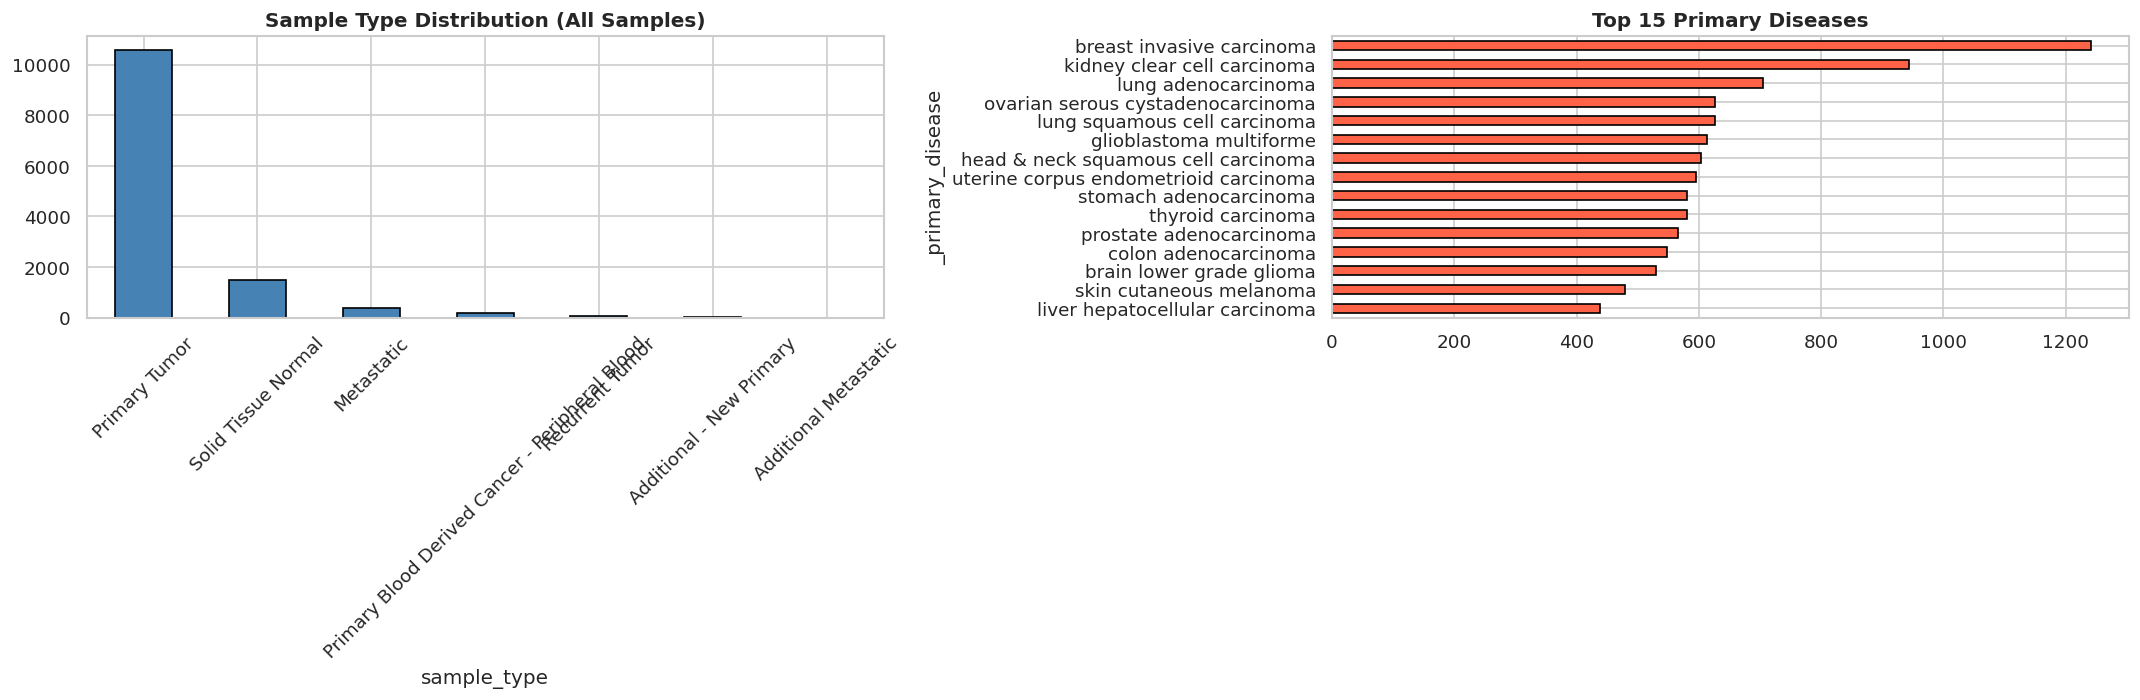


Final Valid Primary Tumor Patients: 10593
Number of Valid Cancer Classes: 32


56

In [2]:
section("1. PHENOTYPE EDA & CLEANING")

pheno_raw = pd.read_csv(path_pheno, sep='\t')
print(f"Raw Phenotype Shape: {pheno_raw.shape}")

# Plot raw distributions
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
pheno_raw['sample_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Sample Type Distribution (All Samples)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

pheno_raw['_primary_disease'].value_counts().head(15).plot(kind='barh', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Top 15 Primary Diseases', fontweight='bold')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

# Clean and Filter Phenotype
pheno = pheno_raw[pheno_raw['sample_type'] == 'Primary Tumor'].copy()
pheno.index = pheno['sample'].str[:15]
pheno = pheno[~pheno.index.duplicated(keep='first')]

# Drop rare cancers (< 20 samples)
type_counts = pheno['_primary_disease'].value_counts()
valid_types = type_counts[type_counts >= 20].index
pheno = pheno[pheno['_primary_disease'].isin(valid_types)]

valid_patients_pheno = set(pheno.index)
print(f"\nFinal Valid Primary Tumor Patients: {len(valid_patients_pheno)}")
print(f"Number of Valid Cancer Classes: {pheno['_primary_disease'].nunique()}")

del pheno_raw # Free RAM
gc.collect()


  2. mRNA EDA & CLEANING
Loading mRNA... (Transposing)
Cleaned mRNA Shape: (11060, 20530)


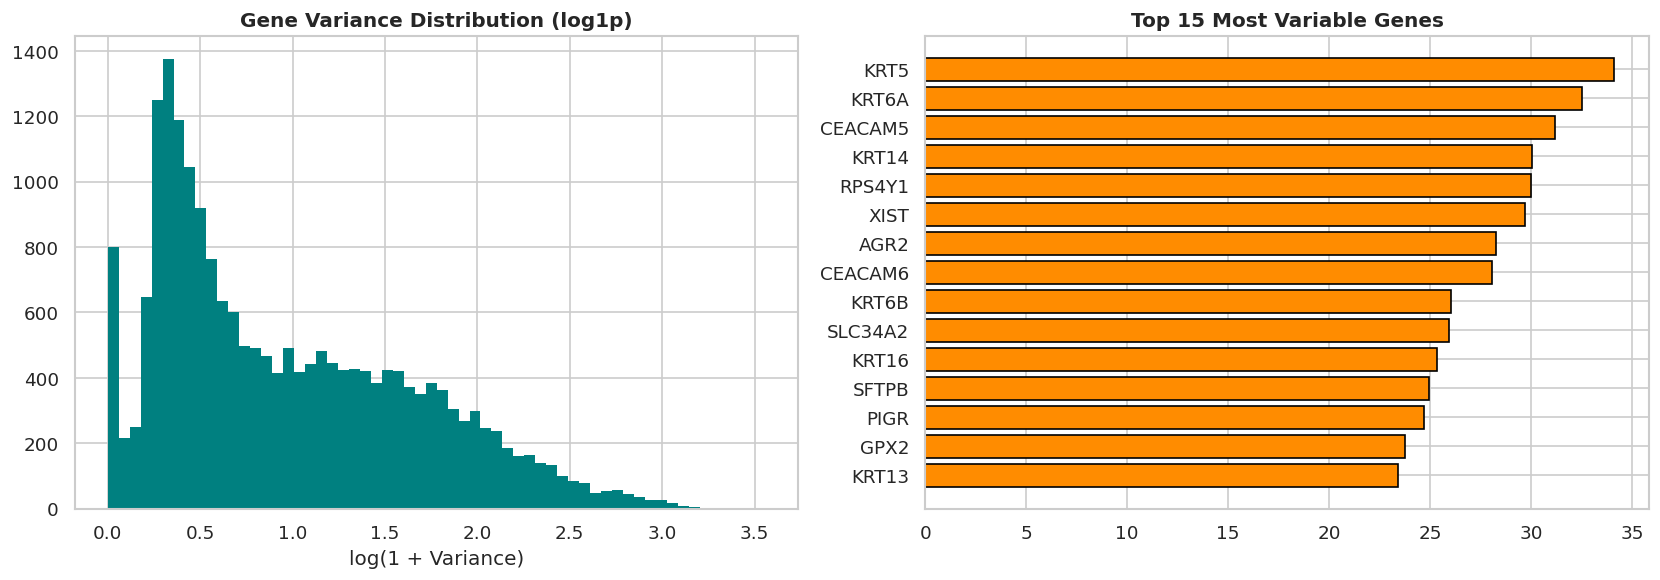


Downcasting mRNA to float32 to save RAM...


7578

In [3]:
section("2. mRNA EDA & CLEANING")

print("Loading mRNA... (Transposing)")
mrna = pd.read_csv(path_mrna, sep='\t', index_col=0).T

# Clean Patient IDs and Gene Names
mrna.index = mrna.index.str[:15]
mrna = mrna[~mrna.index.duplicated(keep='first')]
mrna.columns = [str(col).split('|')[0] for col in mrna.columns]
mrna = mrna.loc[:, ~mrna.columns.duplicated(keep='first')]

print(f"Cleaned mRNA Shape: {mrna.shape}")

# Calculate EDA Stats (Before downcasting)
gene_var = mrna.var(axis=0)
sample_mean = mrna.mean(axis=1)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(np.log1p(gene_var), bins=60, color='teal', edgecolor='none')
axes[0].set_title('Gene Variance Distribution (log1p)', fontweight='bold')
axes[0].set_xlabel('log(1 + Variance)')

top15_var = gene_var.nlargest(15)
axes[1].barh(top15_var.index, top15_var.values, color='darkorange', edgecolor='black')
axes[1].set_title('Top 15 Most Variable Genes', fontweight='bold')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

# Downcast to float32 to save massive RAM (50% reduction)
print("\nDowncasting mRNA to float32 to save RAM...")
mrna = mrna.astype(np.float32)

valid_patients_mrna = set(mrna.index)
valid_genes_mrna = set(mrna.columns)
gc.collect()


  3. CNV EDA & CLEANING
Loading CNV... (Transposing)
Cleaned CNV Shape: (10845, 23705)


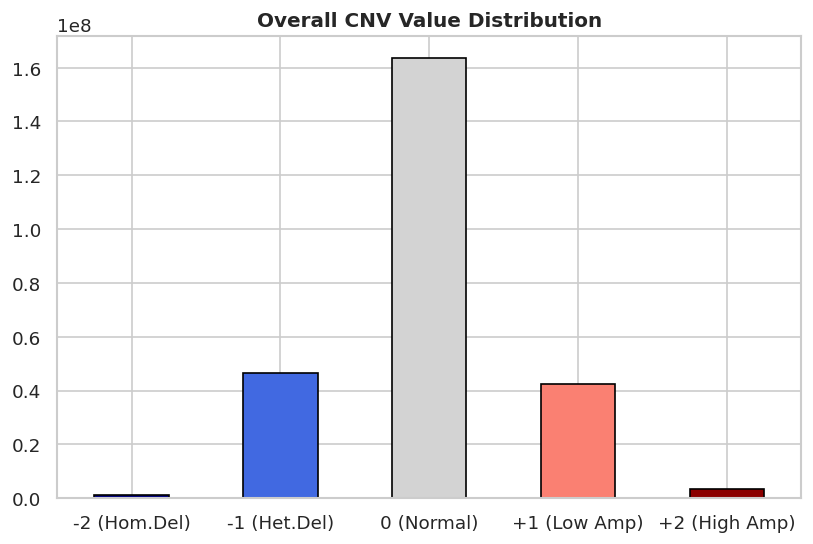


Filling missing values with 0 and downcasting to int8...


0

In [4]:
section("3. CNV EDA & CLEANING")

print("Loading CNV... (Transposing)")
cnv = pd.read_csv(path_cnv, sep='\t', index_col=0).T

# Clean Patient IDs and Gene Names
cnv.index = cnv.index.str[:15]
cnv = cnv[~cnv.index.duplicated(keep='first')]
cnv.columns = [str(col).split('|')[0] for col in cnv.columns]
cnv = cnv.loc[:, ~cnv.columns.duplicated(keep='first')]

print(f"Cleaned CNV Shape: {cnv.shape}")

# Get exact counts of -2 to +2 without blowing up memory
val_counts = cnv.stack().value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
val_counts.plot(kind='bar', color=['navy','royalblue','lightgray','salmon','darkred'], edgecolor='black', ax=ax)
ax.set_title('Overall CNV Value Distribution', fontweight='bold')
ax.set_xticklabels(['-2 (Hom.Del)','-1 (Het.Del)','0 (Normal)','+1 (Low Amp)','+2 (High Amp)'], rotation=0)
plt.show()

# Fill Missing with 0 (Diploid Normal) and downcast to int8 (Saves 87% RAM!)
print("\nFilling missing values with 0 and downcasting to int8...")
cnv = cnv.fillna(0).astype(np.int8)

valid_patients_cnv = set(cnv.index)
valid_genes_cnv = set(cnv.columns)
gc.collect()


  4. MUTATION EDA & CLEANING
Loading Mutation... (Transposing)
Cleaned Mutation Shape: (9104, 40543)


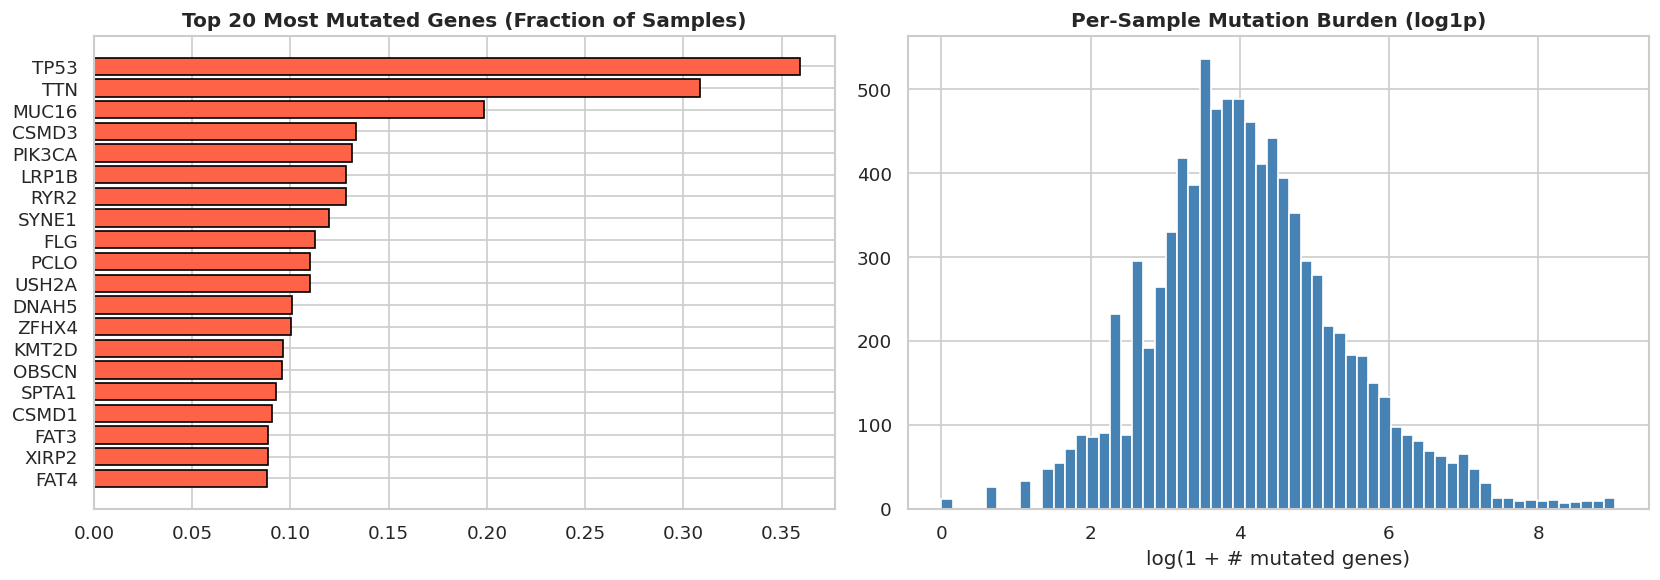


Filling missing values with 0 and downcasting to int8...


10794

In [5]:
section("4. MUTATION EDA & CLEANING")

print("Loading Mutation... (Transposing)")
mut = pd.read_csv(path_mut, sep='\t', index_col=0).T

# Clean Patient IDs and Gene Names
mut.index = mut.index.str[:15]
mut = mut[~mut.index.duplicated(keep='first')]
mut.columns = [str(col).split('|')[0] for col in mut.columns]
mut = mut.loc[:, ~mut.columns.duplicated(keep='first')]

print(f"Cleaned Mutation Shape: {mut.shape}")

# EDA Stats
mut_rate = mut.mean(axis=0)
sample_burden = mut.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top20_mut = mut_rate.nlargest(20)
axes[0].barh(top20_mut.index, top20_mut.values, color='tomato', edgecolor='black')
axes[0].set_title('Top 20 Most Mutated Genes (Fraction of Samples)', fontweight='bold')
axes[0].invert_yaxis()

axes[1].hist(np.log1p(sample_burden), bins=60, color='steelblue')
axes[1].set_title('Per-Sample Mutation Burden (log1p)', fontweight='bold')
axes[1].set_xlabel('log(1 + # mutated genes)')
plt.tight_layout()
plt.show()

# Fill missing with 0 (Wildtype) and downcast to int8
print("\nFilling missing values with 0 and downcasting to int8...")
mut = mut.fillna(0).astype(np.int8)

valid_patients_mut = set(mut.index)
valid_genes_mut = set(mut.columns)
gc.collect()

In [6]:
section("5. PERFECT ALIGNMENT & PREPROCESSING (Matching Papers)")

# 1. Find overlapping Patients & Genes
common_patients = sorted(list(valid_patients_pheno & valid_patients_mrna & valid_patients_cnv & valid_patients_mut))
common_genes = sorted(list(valid_genes_mrna & valid_genes_cnv & valid_genes_mut))

print(f"Total overlapping Patients: {len(common_patients)}")
print(f"Total overlapping Genes: {len(common_genes)}")

# 2. Slice all matrices to identical shapes
mrna = mrna.loc[common_patients, common_genes]
cnv = cnv.loc[common_patients, common_genes]
mut = mut.loc[common_patients, common_genes]
labels = pheno.loc[common_patients, ['_primary_disease']]

# 3. Apply Deep Learning Preprocessing (GexBERT / Pathformer logic)
print("\nImputing final missing mRNA values with gene means...")
mrna = mrna.fillna(mrna.mean())

print("Filtering out bottom 10% low-variance genes from ALL modalities...")
gene_var_final = mrna.var(axis=0)
high_var_genes = gene_var_final[gene_var_final > gene_var_final.quantile(0.10)].index

# Drop the genes from all 3 to keep shapes identical
mrna = mrna[high_var_genes]
cnv = cnv[high_var_genes]
mut = mut[high_var_genes]

print("Applying Z-score normalization to mRNA...")
mrna = (mrna - mrna.mean()) / (mrna.std() + 1e-8)
mrna = mrna.astype(np.float32)

print("\n--- FINAL ALIGNED SHAPES ---")
print(f"mRNA Matrix: {mrna.shape}")
print(f"CNV Matrix:  {cnv.shape}")
print(f"Mut Matrix:  {mut.shape}")
print(f"Labels:      {labels.shape}")

gc.collect()


  5. PERFECT ALIGNMENT & PREPROCESSING (Matching Papers)
Total overlapping Patients: 8225
Total overlapping Genes: 18046

Imputing final missing mRNA values with gene means...
Filtering out bottom 10% low-variance genes from ALL modalities...
Applying Z-score normalization to mRNA...

--- FINAL ALIGNED SHAPES ---
mRNA Matrix: (8225, 16241)
CNV Matrix:  (8225, 16241)
Mut Matrix:  (8225, 16241)
Labels:      (8225, 1)


0


  6. FINAL COMBINED DATASET EDA


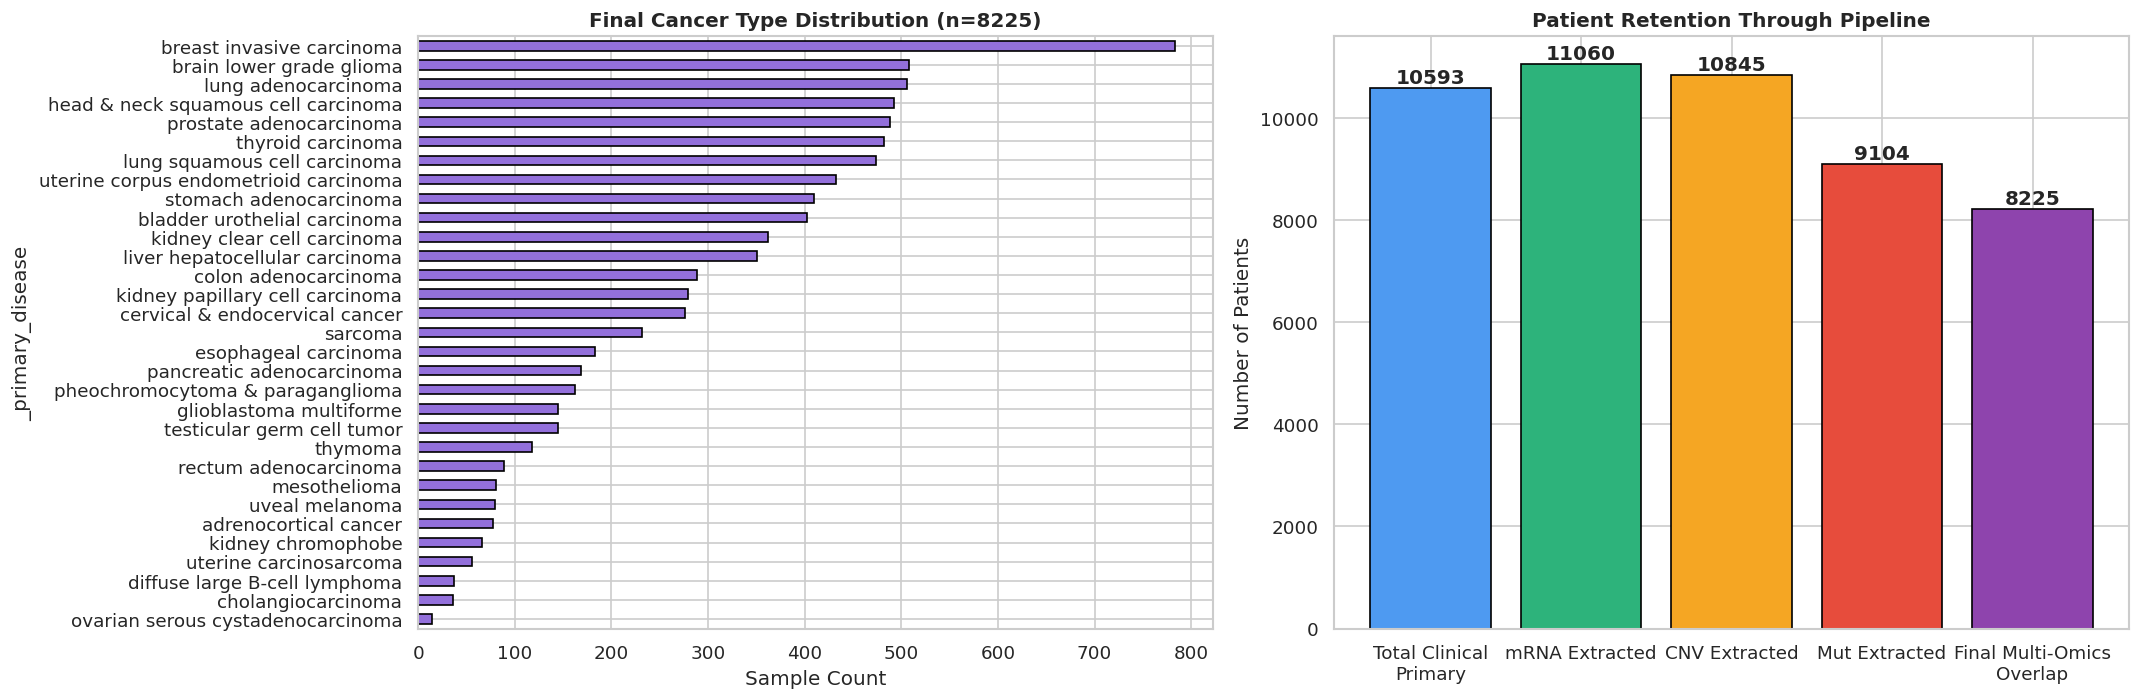

In [7]:
section("6. FINAL COMBINED DATASET EDA")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Class Distribution
class_counts = labels['_primary_disease'].value_counts()
class_counts.plot(kind='barh', ax=axes[0], color='mediumpurple', edgecolor='black')
axes[0].set_title(f'Final Cancer Type Distribution (n={len(common_patients)})', fontweight='bold')
axes[0].set_xlabel('Sample Count')
axes[0].invert_yaxis()

# Overlap Waterfall (Visualizing data retention)
retention = {
    'Total Clinical\nPrimary': len(valid_patients_pheno),
    'mRNA Extracted': len(valid_patients_mrna),
    'CNV Extracted': len(valid_patients_cnv),
    'Mut Extracted': len(valid_patients_mut),
    'Final Multi-Omics\nOverlap': len(common_patients)
}
axes[1].bar(retention.keys(), retention.values(), color=['#4e9af1','#2db37b','#f5a623','#e74c3c','#8e44ad'], edgecolor='black')
axes[1].set_title('Patient Retention Through Pipeline', fontweight='bold')
axes[1].set_ylabel('Number of Patients')
for i, v in enumerate(retention.values()):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
section("7. SAVING SEPARATE FILES FOR PYTORCH")

# We must ensure columns are strings for Parquet saving
mrna.columns = mrna.columns.astype(str)
cnv.columns = cnv.columns.astype(str)
mut.columns = mut.columns.astype(str)

print("Saving as .CSV (This takes longer and uses more disk space)...")
mrna.to_csv('mrna_final.csv')
cnv.to_csv('cnv_final.csv')
mut.to_csv('mut_final.csv')
labels.to_csv('labels_final.csv')

print("Saving as .PARQUET (Highly recommended for deep learning)...")
mrna.to_parquet('mrna_final.parquet')
cnv.to_parquet('cnv_final.parquet')
mut.to_parquet('mut_final.parquet')
labels.to_parquet('labels_final.parquet')

print("\nSUCCESS! All processing complete.")
print("You now have 3 separate, perfectly aligned omics matrices ready for the Multi-Modal Transformer!")


  7. SAVING SEPARATE FILES FOR PYTORCH
Saving as .CSV (This takes longer and uses more disk space)...
Saving as .PARQUET (Highly recommended for deep learning)...

SUCCESS! All processing complete.
You now have 3 separate, perfectly aligned omics matrices ready for the Multi-Modal Transformer!
